In [1]:
from langgraph.graph import StateGraph

In [2]:
from langchain_cohere.embeddings import CohereEmbeddings
cohere_embeddings = CohereEmbeddings(model="embed-english-light-v3.0")

In [3]:
text = "This is a test document."
query_result = cohere_embeddings.embed_query(text)
print(query_result)
print(len(query_result))

[-0.09338379, 0.0871582, -0.03326416, 0.01953125, 0.07702637, 0.034729004, -0.058380127, -0.031021118, -0.030517578, -0.055999756, 0.050842285, -0.006752014, 0.038391113, -0.0014362335, -0.041137695, -0.008880615, 0.026000977, -0.023010254, 0.05456543, -0.03366089, 0.055633545, 0.028579712, -0.068603516, 0.03970337, -0.06677246, 0.06732178, -0.013053894, -0.0060920715, 0.038116455, 0.057800293, 0.048736572, 0.026855469, 0.009849548, 0.08312988, 0.073791504, 0.01663208, -0.0871582, 0.01802063, -0.0020828247, -0.0031356812, 0.039978027, -0.03164673, 0.009796143, 0.011375427, 0.0068855286, 0.092285156, 0.05218506, -0.060943604, 0.038269043, -0.018218994, -0.04510498, -0.0847168, 0.008300781, -0.060058594, 0.0012111664, 0.05102539, 0.05218506, -0.047210693, -0.051239014, -0.044158936, -0.058166504, 0.07849121, -0.019165039, 0.06451416, 0.024887085, 0.011405945, -0.03768921, -0.018814087, -0.06829834, -0.052825928, -0.019104004, -0.021194458, 0.043518066, 0.07525635, 0.082336426, 0.00376510

In [4]:
from langchain_groq import ChatGroq

def LLMinput(state):
    llm = ChatGroq(model="llama-3.1-8b-instant")
    last_message = state["messages"][-1].content
    response = llm.invoke(last_message)
    return {"messages": [response]}

In [5]:
def count_tokens(state):
    last_message = state["messages"][-1].content
    splitted_tokens = last_message.split()
    token_length = f"Total number of tokens in the given sentence is {len(splitted_tokens)}"
    from langchain_core.messages import AIMessage
    return {"messages": [AIMessage(content=token_length)]}

In [6]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage

from langgraph.graph.message import add_messages


class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]


In [7]:
workflow = StateGraph(AgentState)

In [8]:
# from langgraph.graph import END, StateGraph, START
# from langgraph.prebuilt import ToolNode
# from langgraph.prebuilt import tools_condition

# workflow.add_node("My LLM",LLMinput)
# workflow.add_node("Token Count", count_tokens)

# workflow.add_edge(START,"My LLM")
# workflow.add_edge("My LLM","Token Count")
# workflow.add_edge("Token Count",END)

from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Only add nodes if they don't exist
if "My LLM" not in workflow.nodes:
    workflow.add_node("My LLM", LLMinput)
if "Token Count" not in workflow.nodes:
    workflow.add_node("Token Count", count_tokens)

# Add edges (these can be re-added without issue)
workflow.add_edge(START, "My LLM")
workflow.add_edge("My LLM", "Token Count")
workflow.add_edge("Token Count", END)

In [9]:
app = workflow.compile()

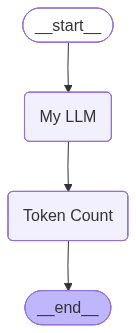

In [10]:
from IPython.display import Image

# Display the graph as a PNG image
Image(app.get_graph().draw_mermaid_png())

In [11]:
from langchain_core.messages import HumanMessage

# Invoke the graph with a proper state dict
result = app.invoke({"messages": [HumanMessage(content="what is agentic ai ?, explain me in short answer")]})

# Print the final response
print(result["messages"][-1].content)

Total number of tokens in the given sentence is 69


In [12]:
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages

# ✅ Define State
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

# ✅ Define a node (your function)
def llm_node(state: AgentState):
    print("STATE INSIDE NODE:", state)

    last_message = state["messages"][-1].content

    # fake LLM response (no API needed)
    response = AIMessage(content=f"Echo: {last_message}")

    return {"messages": [response]}

# ✅ Build graph
graph = StateGraph(AgentState)

graph.add_node("llm_node", llm_node)

graph.set_entry_point("llm_node")
graph.add_edge("llm_node", END)

# ✅ Compile graph
app = graph.compile()

# ✅ Invoke graph (THIS is where state starts)
result = app.invoke({
    "messages": [HumanMessage(content="Hello")]
})

print("\nFINAL RESULT:")
for msg in result["messages"]:
    print(msg)

STATE INSIDE NODE: {'messages': [HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}, id='c9324a57-e689-418a-b1d9-258005004fdb')]}

FINAL RESULT:
content='Hello' additional_kwargs={} response_metadata={} id='c9324a57-e689-418a-b1d9-258005004fdb'
content='Echo: Hello' additional_kwargs={} response_metadata={} id='79786b3f-1024-4448-ae8c-c5a9500a3430' tool_calls=[] invalid_tool_calls=[]


# Basic RAG - Agent

In [13]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_cohere import CohereEmbeddings
from langchain_groq import ChatGroq
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_core.output_parsers import StrOutputParser

In [14]:
import os

os.getcwd()
data_folder = os.path.join(os.getcwd(), '..', 'data')
documents = []
for filename in os.listdir(data_folder):
    if filename.endswith('.txt'):
        file_path = os.path.join(data_folder, filename)
        loader = TextLoader(file_path)
        documents.extend(loader.load())


splitter = RecursiveCharacterTextSplitter(chunk_size=200, chunk_overlap=30)
split_docs = splitter.split_documents(documents)
len(split_docs)

vectorstore = FAISS.from_documents(split_docs, cohere_embeddings)
customer_it_support_db = vectorstore.save_local("customer_it_support_db")
customer_it_support_db = FAISS.load_local("customer_it_support_db",cohere_embeddings,allow_dangerous_deserialization=True)
customer_it_support_db_retriever = customer_it_support_db.as_retriever(search_type="mmr",search_kwargs={"fetch_k": 3})

In [15]:
customer_it_support_db_retriever

VectorStoreRetriever(tags=['FAISS', 'CohereEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x0000026433781DC0>, search_type='mmr', search_kwargs={'fetch_k': 3})

In [16]:
# ✅ Define State
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [17]:
llm = ChatGroq(model="llama-3.1-8b-instant")

In [18]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.messages import AIMessage

def function_1(state):
    message = state['messages'][-1]
    question = message.content

    complete_prompt="Your task is to provide only the brief answer based on the user query." \
    "Don't include too much reasoning.following is the user query :"+question
    

    response = llm.invoke(complete_prompt)
    state['messages'].append(AIMessage(content=response.content))

    return state 

def function_2(state):

    message = state['messages']

    question = message[0].content # fetching the user question

    template = """Answer the qustion based only the following context : {context}
    Question :{question}"""

    prompt = ChatPromptTemplate.from_template(template)

    retrieval_chain = (
        {"context":customer_it_support_db_retriever,"question":RunnablePassthrough()}
        | prompt
        |llm
        | StrOutputParser()
    )

    result = retrieval_chain.invoke(question)

    return {"messages": [AIMessage(content=result)]}

In [19]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

workflow1 = StateGraph(AgentState)

workflow1.add_node("LLM", function_1)
workflow1.add_node("RAG Tool", function_2)
workflow1.add_edge(START, "LLM")
workflow1.add_edge("LLM", "RAG Tool")
workflow1.add_edge("RAG Tool", END)

app1 = workflow1.compile()

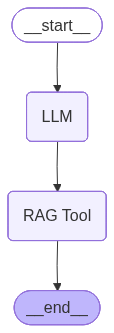

In [20]:
# Display the graph as a PNG image
Image(app1.get_graph().draw_mermaid_png())

In [21]:
from langchain_core.messages import HumanMessage

response = app1.invoke({"messages": [HumanMessage(content="what is agentic ai?")]})
print(response['messages'])

[HumanMessage(content='what is agentic ai?', additional_kwargs={}, response_metadata={}, id='7704c69f-bffa-43ce-82ab-d7adb9a66f16'), AIMessage(content='Agentic AI refers to artificial intelligence that exhibits autonomous behavior, goal-directedness, and decision-making capabilities, similar to human agency.', additional_kwargs={}, response_metadata={}, id='72b6e576-33aa-4718-b64b-23eb0098480d', tool_calls=[], invalid_tool_calls=[]), AIMessage(content='I don\'t see any information in the provided context about "agentic AI". The context appears to be related to documentation about access management and incident response, but it does not mention artificial intelligence or any related topics.', additional_kwargs={}, response_metadata={}, id='59c60b63-8349-41f6-a413-79432cec01a1', tool_calls=[], invalid_tool_calls=[])]


In [22]:
from langchain_core.messages import HumanMessage

for output in app1.stream({"messages": [HumanMessage(content="what is agentic ai?")]}):
    for key, value in output.items():
        print(f"here is the output from : {key}")
        print("=="*40)
        print(value)
        print("\n")

here is the output from : LLM
{'messages': [HumanMessage(content='what is agentic ai?', additional_kwargs={}, response_metadata={}, id='e246f62f-c357-4282-95d2-9cca7cec8477'), AIMessage(content='Agentic AI refers to artificial intelligence systems that exhibit autonomous decision-making and goal-directed behavior, similar to human agency.', additional_kwargs={}, response_metadata={}, id='9363bab9-96af-4ec8-b210-48a495b4be7f', tool_calls=[], invalid_tool_calls=[])]}


here is the output from : RAG Tool
{'messages': [AIMessage(content='There is no information about "Agentic AI" in the given context. The context appears to be about documentation related to access management and incident response, but it does not mention anything about Agentic AI.', additional_kwargs={}, response_metadata={}, id='e9a26454-6c36-4243-8ff0-a2ed7dcfcf95', tool_calls=[], invalid_tool_calls=[])]}


